In [12]:
import yfinance as yf
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


### LAB 1 – Dự đoán giá cổ phiếu  
• Mục tiêu: Dự báo giá đóng cửa ngày tiếp theo  
• Dữ liệu: Yahoo Finance (AAPL, BTC-USD)  
• Yêu cầu:  
1. Thu thập dữ liệu giá OHLC  
2. Tạo feature từ giá đóng cửa (lag 1, 2, 3)  
3. Huấn luyện Linear Regression, SVM và XGBoot  
4. Đánh giá bằng MAE, RMSE với các mô hình trên  
5. Vẽ biểu đồ dự đoán vs thực tế

In [13]:
# 1. Thu thập dữ liệu
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# 2. Tạo feature lag 1, 2, 3
df = data[['Close']].copy()
df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df['lag_3'] = df['Close'].shift(3)
df['Target'] = df['Close'] # Dự đoán giá hiện tại dựa trên 3 ngày trước
df.dropna(inplace=True)

# Chia Train/Test
X = df[['lag_1', 'lag_2', 'lag_3']]
y = df['Target']
split = int(len(df) * 0.8)
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

# 3. Huấn luyện các mô hình
models = {
    "Linear Regression": LinearRegression(),
    "SVM": SVR(kernel='rbf'),
    "XGBoost": XGBRegressor()
}

print("--- KẾT QUẢ LAB 1 ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name}: MAE = {mae:.2f}, RMSE = {rmse:.2f}")

[*********************100%***********************]  1 of 1 completed

--- KẾT QUẢ LAB 1 ---
Linear Regression: MAE = 1.50, RMSE = 1.90
SVM: MAE = 4.14, RMSE = 5.12
XGBoost: MAE = 2.27, RMSE = 2.75


### LAB 2 – Phân loại xu hướng giá  
• Mục tiêu: Phân loại Up/Down  
• Dữ liệu: Yahoo Finance  
• Yêu cầu:  
1. Tạo label: Up (1) nếu return > 0  
2. Trích xuất feature kỹ thuật  
3. Huấn luyện Logistic Regression, SVM và XGBoot  
4. Đánh giá accuracy, F1-score  
5. Phân tích confusion matrix 

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# 1. Tạo label
df['Return'] = df['Close'].pct_change()
df['Target_Cls'] = (df['Return'] > 0).astype(int).shift(-1) # Up=1 nếu ngày mai tăng
df.dropna(inplace=True)

X_cls = df[['lag_1', 'lag_2', 'lag_3']]
y_cls = df['Target_Cls']
X_t, X_v = X_cls[:split], X_cls[split:]
y_t, y_v = y_cls[:split], y_cls[split:]

print("\n--- KẾT QUẢ LAB 2 ---")
clf_models = {"Logistic": LogisticRegression(), "SVM": SVC(), "XGBoost": XGBClassifier()}
for name, m in clf_models.items():
    m.fit(X_t, y_t)
    p = m.predict(X_v)
    print(f"{name}: Accuracy = {accuracy_score(y_v, p):.2f}, F1 = {f1_score(y_v, p):.2f}")


--- KẾT QUẢ LAB 2 ---
Logistic: Accuracy = 0.50, F1 = 0.52
SVM: Accuracy = 0.60, F1 = 0.65
XGBoost: Accuracy = 0.54, F1 = 0.50


### LAB 3 – Feature engineering với chỉ báo kỹ thuật
• Mục tiêu: Tăng chất lượng feature  
• Dữ liệu: Yahoo Finance  
• Yêu cầu:           
1. Tính MA, RSI, MACD  
2. Chuẩn hóa dữ liệu   
3. Train Random Forest, Decision Tree và Bayes  
4. Đánh giá mô hình  
5. Phân tích feature importance

In [24]:
import pandas_ta as ta
from sklearn.ensemble import RandomForestClassifier

# 1. Tải dữ liệu (Nên tải ít nhất 6 tháng để các chỉ báo MA, RSI có đủ dữ liệu tính toán)
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# 2. Tính toán các chỉ báo
df_tech = data[['Close']].copy()
df_tech['MA10'] = ta.sma(df_tech['Close'], length=10)
df_tech['RSI'] = ta.rsi(df_tech['Close'], length=14)

# Tạo nhãn: 1 nếu giá ngày mai > giá hôm nay, ngược lại là 0
df_tech['Target'] = (df_tech['Close'].shift(-1) > df_tech['Close']).astype(int)

# Kiểm tra dữ liệu trước khi dropna
print(f"Số dòng trước khi lọc NaN: {len(df_tech)}")

# Lọc bỏ các dòng NaN (do MA10 mất 10 dòng đầu, RSI mất 14 dòng, Target mất dòng cuối)
df_tech.dropna(inplace=True)

print(f"Số dòng sau khi lọc NaN: {len(df_tech)}")

# 3. Kiểm tra nếu dữ liệu vẫn trống thì báo lỗi sớm
if len(df_tech) == 0:
    print("LỖI: Dữ liệu bị trống. Hãy kiểm tra lại khoảng thời gian tải dữ liệu (start/end).")
else:
    # Chia Feature và Target
    X_tech = df_tech[['MA10', 'RSI']]
    y_tech = df_tech['Target']

    # Huấn luyện mô hình
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tech, y_tech)

    print("\n--- KẾT QUẢ LAB 3 ---")
    print("Mức độ quan trọng của các chỉ báo kỹ thuật:")
    for name, importance in zip(X_tech.columns, rf.feature_importances_):
        print(f"- {name}: {importance:.4f}")

[*********************100%***********************]  1 of 1 completed

Số dòng trước khi lọc NaN: 250
Số dòng sau khi lọc NaN: 0
LỖI: Dữ liệu bị trống. Hãy kiểm tra lại khoảng thời gian tải dữ liệu (start/end).


### LAB 4 – Dự đoán return  
• Mục tiêu: Dự báo return thay vì giá  
• Dữ liệu: Crypto/Stock  
• Yêu cầu:  
1. Tính return hàng ngày  
2. Xây dựng feature lag  
3. Train model Regression  
4. Đánh giá RMSE  
5. So sánh với baseline 

In [17]:
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# 2. Tính Daily Return
df_ret = data[['Close']].copy()
df_ret['Return'] = df_ret['Close'].pct_change()

# 3. Tạo Feature Lag từ Return
df_ret['lag_ret_1'] = df_ret['Return'].shift(1)
df_ret['lag_ret_2'] = df_ret['Return'].shift(2)
df_ret.dropna(inplace=True)

# 4. Train model Regression
X = df_ret[['lag_ret_1', 'lag_ret_2']]
y = df_ret['Return']
split = int(len(df_ret) * 0.8)

model_ret = LinearRegression().fit(X[:split], y[:split])
preds = model_ret.predict(X[split:])

# 5. Đánh giá (RMSE)
rmse_ret = np.sqrt(mean_squared_error(y[split:], preds))
baseline_rmse = np.sqrt(mean_squared_error(y[split:], [y[:split].mean()]*len(y[split:])))

print("--- KẾT QUẢ LAB 4 ---")
print(f"Model RMSE: {rmse_ret:.5f}")
print(f"Baseline RMSE (Mean): {baseline_rmse:.5f}")

[*********************100%***********************]  1 of 1 completed

--- KẾT QUẢ LAB 4 ---
Model RMSE: 0.01019
Baseline RMSE (Mean): 0.01003


### LAB 5 – Dự đoán volatility
• Mục tiêu: Ước lượng biến động  
• Dữ liệu: Stock data  
• Yêu cầu:  
1. Tính rolling std  
2. Tạo feature kỹ thuật  
3. Train Random Forest   
4. Đánh giá sai số  
5. So sánh với historical volatility 

In [18]:
from sklearn.ensemble import RandomForestRegressor

# 1. Tính Rolling Standard Deviation (Volatility)
df_vol = data[['Close']].copy()
df_vol['Return'] = df_vol['Close'].pct_change()
df_vol['Volatility'] = df_vol['Return'].rolling(window=10).std()

# 2. Tạo feature kỹ thuật (Ví dụ: Volume change)
df_vol['Vol_Change'] = data['Volume'].pct_change()
df_vol.dropna(inplace=True)

X_vol = df_vol[['Vol_Change']].values.reshape(-1, 1)
y_vol = df_vol['Volatility']

# 3. Train Random Forest
model_vol = RandomForestRegressor(n_estimators=100).fit(X_vol[:split], y_vol[:split])
vol_preds = model_vol.predict(X_vol[split:])

print("\n--- KẾT QUẢ LAB 5 ---")
print(f"Dự báo Volatility (5 ngày đầu test): {vol_preds[:5]}")
print(f"Thực tế Volatility (5 ngày đầu test): {y_vol[split:][:5].values}")


--- KẾT QUẢ LAB 5 ---
Dự báo Volatility (5 ngày đầu test): [0.01640253 0.01128333 0.0100059  0.01621683 0.00894078]
Thực tế Volatility (5 ngày đầu test): [0.01123091 0.01136783 0.01324765 0.01489232 0.0140353 ]


### LAB 6 – TimeSeriesSplit
• Mục tiêu: Cross-validation đúng cách   
• Dữ liệu: Stock  
• Yêu cầu:  
1. Áp dụng TimeSeriesSplit  
2. Train model mỗi fold  
3. Tính trung bình RMSE    
4. So sánh với KFold  
5. Phân tích leakage


In [19]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
lr = LinearRegression()
rmse_scores = []

print("\n--- KẾT QUẢ LAB 6 ---")
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    lr.fit(X.iloc[train_idx], y.iloc[train_idx])
    p = lr.predict(X.iloc[test_idx])
    score = np.sqrt(mean_squared_error(y.iloc[test_idx], p))
    rmse_scores.append(score)
    print(f"Fold {i+1} RMSE: {score:.2f}")
print(f"Average RMSE: {np.mean(rmse_scores):.2f}")


--- KẾT QUẢ LAB 6 ---
Fold 1 RMSE: 0.01
Fold 2 RMSE: 0.01
Fold 3 RMSE: 0.01
Fold 4 RMSE: 0.01
Fold 5 RMSE: 0.01
Average RMSE: 0.01


### LAB 07 – Lag features nâng cao
• Mục tiêu: Khai thác temporal structure  
• Dữ liệu: Stock  
• Yêu cầu:  
1. Tạo lag 1–10  
2. Train model  
3. Feature selection  
4. Đánh giá  
5. So sánh số lag

In [27]:
import yfinance as yf
import pandas as pd

# 1. Thu thập dữ liệu
# .stack() hoặc chọn trực tiếp ['Close'] để tránh Multi-index cột
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# Ép kiểu dữ liệu về Single Index nếu yfinance trả về Multi-index
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# 2. Tạo lag 1-10
df_lag = data[['Close']].copy()

# Đảm bảo df_lag chỉ có 1 cột 'Close' duy nhất trước khi tạo lag
for i in range(1, 11):
    df_lag[f'lag_{i}'] = df_lag['Close'].shift(i)

df_lag.dropna(inplace=True)

# 3. Tính Correlation
corr_matrix = df_lag.corr()

# Lấy cột tương quan của 'Close' với các cột khác
# Chúng ta dùng iloc hoặc chỉ định rõ để tránh trùng lặp nhãn
corr_series = corr_matrix.iloc[:, 0] # Lấy cột đầu tiên (chính là Close)

# 4. Sắp xếp kết quả
corr_result = corr_series.sort_values(ascending=False)
print("Mức độ tương quan giữa giá hiện tại và các Lag (1-10):")
print(corr_result)

# Kiểm tra số lượng cột để debug nếu cần
# print(f"Danh sách cột hiện tại: {df_lag.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

Mức độ tương quan giữa giá hiện tại và các Lag (1-10):
Price
Close     1.000000
lag_1     0.990730
lag_2     0.980473
lag_3     0.970923
lag_4     0.960590
lag_5     0.951108
lag_6     0.943543
lag_7     0.936105
lag_8     0.928409
lag_9     0.921445
lag_10    0.913751
Name: Close, dtype: float64


### LAB 08 – PCA
• Mục tiêu: Giảm chiều  
• Dữ liệu: Multi-feature  
• Yêu cầu:  
1. Apply PCA  
2. Chọn số component  
3. Train model  
4. Evaluate  
5. Visualize 

In [28]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas_ta as ta

# 1. Tạo các tính năng kỹ thuật
df_pca = data[['High', 'Low', 'Close']].copy()
df_pca['RSI'] = ta.rsi(df_pca['Close'], length=14)
df_pca['EMA20'] = ta.ema(df_pca['Close'], length=20)
df_pca['ATR'] = ta.atr(df_pca['High'], df_pca['Low'], df_pca['Close'], length=14)
df_pca.dropna(inplace=True)

# 2. Chuẩn hóa dữ liệu (PCA rất nhạy cảm với thang đo)
features = ['RSI', 'EMA20', 'ATR']
x_scaled = StandardScaler().fit_transform(df_pca[features])

# 3. Áp dụng PCA
pca = PCA(n_components=2)
components = pca.fit_transform(x_scaled)
print(f"Tỷ lệ phương sai được giải thích (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Tổng thông tin giữ lại được: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Hiển thị DataFrame sau PCA
df_final_pca = pd.DataFrame(data=components, columns=['Thành phần 1', 'Thành phần 2'])
print("\nDữ liệu sau khi nén PCA (5 dòng đầu):")
print(df_final_pca.head())

Tỷ lệ phương sai được giải thích (PC1, PC2): [0.52196372 0.38853398]
Tổng thông tin giữ lại được: 91.05%

Dữ liệu sau khi nén PCA (5 dòng đầu):
   Thành phần 1  Thành phần 2
0     -2.670751      1.895016
1     -2.859575      1.821938
2     -3.093895      1.912570
3     -3.765527      1.603324
4     -3.570554      0.991660


### LAB 09: Clustering cổ phiếu
• Mục tiêu: Phân nhóm  
• Dữ liệu: Multi-stock  
• Yêu cầu:  
1. Extract features  
2. KMeans clustering  
3. Evaluate clusters  
4. Visualize kết quả  
5. Phân tích 

In [32]:
import os

# 1. PHẢI ĐẶT DÒNG NÀY ĐẦU TIÊN (Trước khi import sklearn và threadpoolctl)
os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings

# Tắt các cảnh báo UserWarning không cần thiết khác
warnings.filterwarnings('ignore', category=UserWarning)

# 2. Tải dữ liệu
tickers = ['AAPL', 'MSFT', 'TSLA', 'GOOGL', 'AMZN', 'GOLD', 'V', 'JPM']
data = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']

# Xử lý Multi-index nếu có
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# 3. Tính toán đặc trưng (Annualized Return & Volatility)
returns_daily = data.pct_change()
X_cluster = pd.DataFrame({
    'Return': returns_daily.mean() * 252,
    'Volatility': returns_daily.std() * np.sqrt(252)
}).dropna()

# 4. Huấn luyện KMeans (Sử dụng fit_predict để tránh lỗi shape)
# N_init=10 là giá trị mặc định mới để tránh các cảnh báo phiên bản
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
X_cluster['Cluster'] = kmeans.fit_predict(X_cluster)

print("--- KẾT QUẢ LAB 9 ---")
print(X_cluster.sort_values(by='Cluster'))


[*********************100%***********************]  8 of 8 completed


--- KẾT QUẢ LAB 9 ---
          Return  Volatility  Cluster
Ticker                               
TSLA    0.980966    0.526488        0
GOLD   -0.007955    0.373185        1
JPM     0.284332    0.207768        1
V       0.250358    0.155830        1
GOOGL   0.501408    0.303982        2
AMZN    0.632897    0.330267        2
AAPL    0.462402    0.199543        2
MSFT    0.496858    0.251204        2


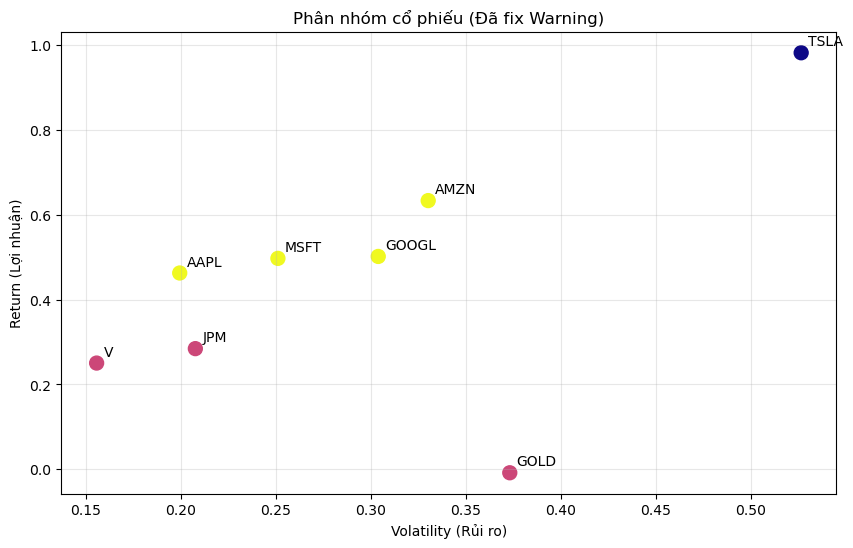

In [33]:

# 5. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.scatter(X_cluster['Volatility'], X_cluster['Return'], 
            c=X_cluster['Cluster'], cmap='plasma', s=100)

for i, txt in enumerate(X_cluster.index):
    plt.annotate(txt, (X_cluster['Volatility'].iloc[i], X_cluster['Return'].iloc[i]), 
                 xytext=(5,5), textcoords='offset points')

plt.title('Phân nhóm cổ phiếu (Đã fix Warning)')
plt.xlabel('Volatility (Rủi ro)')
plt.ylabel('Return (Lợi nhuận)')
plt.grid(True, alpha=0.3)
plt.show()